In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Model
from keras.layers import Dense, Input, Dropout, LSTM, Activation
from keras.layers.embeddings import Embedding
from keras.preprocessing import sequence
from keras.initializers import glorot_uniform

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# https://www.kaggle.com/competitions/tweet-sentiment-extraction/overview
# 3 emotions, approx 30k labelled tweets
df_train = pd.read_csv("/content/train.csv",encoding='ISO-8859-1',header=None)

In [4]:
df_train.drop(columns=[2,0],inplace=True)

In [5]:
df_test = pd.read_csv("/content/test.csv",encoding='ISO-8859-1',header=None)

In [6]:
df_test.drop(columns=[0],inplace=True)

In [7]:
df_test.drop([df_test.index[0]],inplace=True)
df_train.drop([df_train.index[0]],inplace=True)

In [8]:
df_test.columns = ['text','Sentiment']
df_train.columns = ['text','Sentiment']

In [9]:
df_train.dropna(axis=0,inplace=True)
df_test.dropna(axis=0,inplace=True)

In [10]:
# Function to Clean the Tweet.
import re
def clean_tweet(tweet):
    return ' '.join(re.sub('(\\\\n)|(b\"[^0-9A-Za-z A-Za-z0-9 \t]+)|(b\'[^0-9A-Za-z]+)|(b\"[A-Za-z0-9]+)|(b\'[A-Za-z0-9]+)|(b\'#[A-Za-z0-9]+)|(b\'@[A-Za-z0-9]+)|(\\\\x[A-Za-z0-9]+)|(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|([RT])', ' ', str(tweet).lower()).split())


In [11]:
# Call function to get Clean tweets
df_test["CleanTweet"] = df_test['text'].apply(lambda x : clean_tweet(x))
df_train["CleanTweet"] = df_train['text'].apply(lambda x : clean_tweet(x))

In [12]:
df_test.drop(df_test.index[df_test.CleanTweet.eq("")], inplace=True)
df_train.drop(df_train.index[df_train.CleanTweet.eq("")], inplace=True)

In [13]:
#Emotion dictionary lookup
emotions_dict = {"negative":0, "neutral":2, "positive":4}
emotions_dict

def emo_lookup(emo):
  return emotions_dict[emo]

df_test['Label'] = df_test.Sentiment.apply(emo_lookup)
df_train['Label'] = df_train.Sentiment.apply(emo_lookup)

In [14]:
X_train = df_train.CleanTweet
X_test = df_test.CleanTweet
Y_train = df_train.Label
Y_test = df_test.Label

In [15]:
from keras.preprocessing.text import Tokenizer
tk = Tokenizer(num_words=50000,
filters='!"#$%&()*+,-./:;<=>?@[\]^_`{"}~\t\n',lower=True, split=" ")
tk.fit_on_texts(X_train)
X_train_seq = tk.texts_to_sequences(X_train)
X_test_seq = tk.texts_to_sequences(X_test)

In [16]:
from keras.preprocessing.sequence import pad_sequences
X_train_seq_trunc = pad_sequences(X_train_seq, maxlen=50)
X_test_seq_trunc = pad_sequences(X_test_seq, maxlen=50)

In [17]:
from keras.utils.np_utils import to_categorical
y_train_oh = to_categorical(Y_train)
y_test_oh = to_categorical(Y_test)

In [18]:
from sklearn.model_selection import train_test_split
X_train_emb, X_valid_emb, y_train_emb, y_valid_emb = train_test_split(X_train_seq_trunc, y_train_oh, test_size=0.1, random_state=37)

In [19]:
from keras import models
from keras import layers
emb_model = models.Sequential()
emb_model.add(layers.Embedding(50000, 100, input_length=50))
emb_model.add(layers.Flatten())
emb_model.add(layers.Dense(5, activation='softmax'))

In [20]:
y_train_emb

array([[0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.]], dtype=float32)

In [21]:
emb_model.compile(optimizer='rmsprop'
                  , loss='categorical_crossentropy'
                  , metrics=['accuracy'])

history = emb_model.fit(X_train_emb
                       , y_train_emb
                       , epochs=10
                       , batch_size=32
                       , validation_data=(X_valid_emb, y_valid_emb)
                       , verbose=0)

In [21]:
def eval_metric(history, metric_name):
    metric = history.history[metric_name]
    val_metric = history.history['val_' + metric_name]

    e = range(1, 5 + 1)

    plt.plot(e, metric, 'bo', label='Train ' + metric_name)
    plt.plot(e, val_metric, 'b', label='Validation ' + metric_name)
    plt.legend()
    plt.show()

In [23]:
history.history

{'loss': [0.9123469591140747,
  0.6670106053352356,
  0.5594232082366943,
  0.4585155248641968,
  0.3665636479854584,
  0.28969258069992065,
  0.22856755554676056,
  0.18307200074195862,
  0.14808253943920135,
  0.12193047255277634],
 'accuracy': [0.5606955289840698,
  0.7273756861686707,
  0.7853214740753174,
  0.8338050842285156,
  0.8729882836341858,
  0.9031540751457214,
  0.9271734952926636,
  0.9428629279136658,
  0.954063892364502,
  0.9620703458786011],
 'val_loss': [0.7830453515052795,
  0.7600056529045105,
  0.7821622490882874,
  0.8197441101074219,
  0.8645901679992676,
  0.9289631843566895,
  0.9933085441589355,
  1.0690275430679321,
  1.1455576419830322,
  1.228468656539917],
 'val_accuracy': [0.6564774513244629,
  0.6870450973510742,
  0.6812227368354797,
  0.6724891066551208,
  0.6648471355438232,
  0.6532023549079895,
  0.6401019096374512,
  0.6408296823501587,
  0.6346433758735657,
  0.6291848421096802]}

In [24]:
history.history['accuracy'][-1]

0.9620703458786011

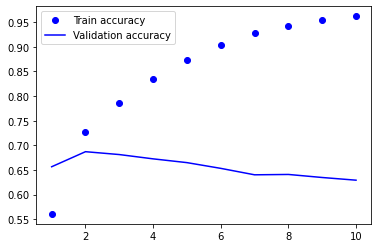

In [30]:
eval_metric(history, 'accuracy')

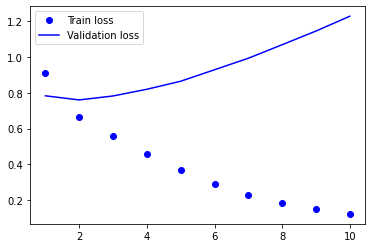

In [31]:
eval_metric(history, 'loss')

In [32]:
results = emb_model.evaluate(X_test_seq_trunc, y_test_oh)
print('/n')
print('Test accuracy of custom word embeddings model: {0:.2f}%'.format(results[1]*100))

111/111 [==============================] - 0s 2ms/step - loss: 1.1448 - accuracy: 0.6451
/n
Test accuracy of custom word embeddings model: 64.51%


In [23]:
emb_dict = {}
glove = open('/content/glove.6B.50d.txt')
for line in glove:
    values = line.split()
    word = values[0]
    vector = np.asarray(values[1:], dtype='float32')
    emb_dict[word] = vector
glove.close()

In [24]:
emb_matrix = np.zeros((50000, 50))
for w, i in tk.word_index.items():
    if i < 50000:
        vect = emb_dict.get(w)
        if vect is not None:
          emb_matrix[i] = vect
    else:
        print(i)
        #break

In [ ]:
tk.word_index.items()

In [36]:
emb_matrix.shape

(50000, 50)

In [37]:
glove_model = models.Sequential()
glove_model.add(layers.Embedding(50000, 50, input_length=50))
glove_model.add(layers.Flatten())
glove_model.add(layers.Dense(5, activation='softmax'))

In [38]:
glove_model.layers[0].set_weights([emb_matrix])
glove_model.layers[0].trainable = False

In [39]:
glove_model.compile(optimizer='rmsprop'
                  , loss='categorical_crossentropy'
                  , metrics=['accuracy'])

glove_history = glove_model.fit(X_train_emb
                       , y_train_emb
                       , epochs=10
                       , batch_size=32
                       , validation_data=(X_valid_emb, y_valid_emb)
                       , verbose=0)

In [40]:
glove_history.history['accuracy'][-1]

0.6039223670959473

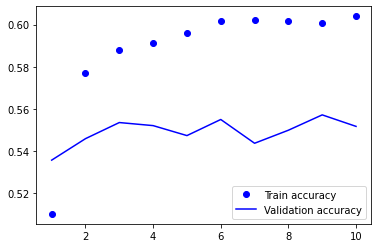

In [41]:
eval_metric(glove_history, 'accuracy')

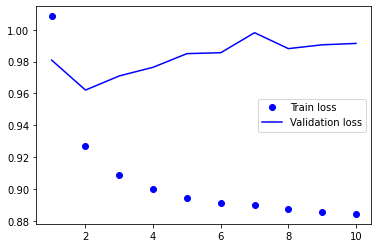

In [42]:
eval_metric(glove_history, 'loss')

In [43]:
results = glove_model.evaluate(X_test_seq_trunc, y_test_oh)
print('/n')
print('Test accuracy of Glove embeddings model: {0:.2f}%'.format(results[1]*100))

111/111 [==============================] - 0s 2ms/step - loss: 0.9824 - accuracy: 0.5596
/n
Test accuracy of Glove embeddings model: 55.96%


In [25]:
# Define Keras embedding layer with the correct output/input sizes, make it non-trainable. Use Embedding(...). Make sure to set trainable=False. 
embedding_layer = Embedding(50000, 50, trainable=False)

# Build the embedding layer, it is required before setting the weights of the embedding layer. Do not modify the "None".
embedding_layer.build((None,))

# Set the weights of the embedding layer to the embedding matrix. Your layer is now pretrained.
embedding_layer.set_weights([emb_matrix])

In [26]:
sentence_indices = Input(shape=(50,),dtype='int32')

In [27]:
# Propagate sentence_indices through your embedding layer, you get back the embeddings
embeddings = embedding_layer(sentence_indices) 

In [28]:
# Propagate the embeddings through an LSTM layer with 128-dimensional hidden state
    # Be careful, the returned output should be a batch of sequences.
X = LSTM(128, return_sequences=True)(embeddings)
    # Add dropout with a probability of 0.5
X = Dropout(0.5)(X)
    # Propagate X trough another LSTM layer with 128-dimensional hidden state
    # Be careful, the returned output should be a single hidden state, not a batch of sequences.
X = LSTM(128, return_sequences=False)(embeddings)
    # Add dropout with a probability of 0.5
X = Dropout(0.5)(X)
    # Propagate X through a Dense layer with softmax activation to get back a batch of 3-dimensional vectors.
X = Dense(5, activation=None)(X)
    # Add a softmax activation
X = Activation('softmax')(X)
    
    # Create Model instance which converts sentence_indices into X.
lstm_model = Model(inputs=[sentence_indices], outputs=X)

In [29]:
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [30]:
lstm_history = lstm_model.fit(X_train_emb, y_train_emb, epochs = 5, batch_size = 32, validation_data=(X_valid_emb, y_valid_emb),shuffle=True)

Epoch 1/5
773/773 [==============================] - 43s 53ms/step - loss: 0.9341 - accuracy: 0.5575 - val_loss: 0.8226 - val_accuracy: 0.6386
Epoch 2/5
773/773 [==============================] - 42s 54ms/step - loss: 0.7989 - accuracy: 0.6512 - val_loss: 0.7785 - val_accuracy: 0.6587
Epoch 3/5
773/773 [==============================] - 40s 52ms/step - loss: 0.7545 - accuracy: 0.6757 - val_loss: 0.7402 - val_accuracy: 0.6870
Epoch 4/5
773/773 [==============================] - 40s 51ms/step - loss: 0.7284 - accuracy: 0.6911 - val_loss: 0.7185 - val_accuracy: 0.6980
Epoch 5/5
773/773 [==============================] - 40s 52ms/step - loss: 0.7047 - accuracy: 0.7020 - val_loss: 0.7067 - val_accuracy: 0.7045


In [31]:
results = lstm_model.evaluate(X_test_seq_trunc, y_test_oh)
print('/n')
print('Test accuracy of LSTM Glove model: {0:.2f}%'.format(results[1]*100))

111/111 [==============================] - 2s 19ms/step - loss: 0.7091 - accuracy: 0.6872
/n
Test accuracy of LSTM Glove model: 68.72%


In [32]:
lstm_history.history['accuracy'][-1]

0.7020218372344971

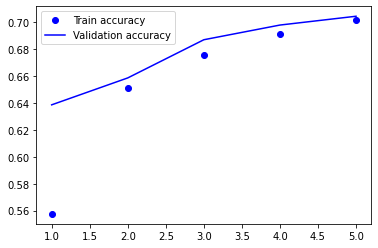

In [33]:
eval_metric(lstm_history, 'accuracy')

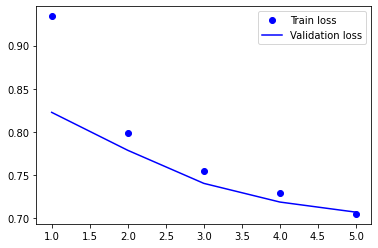

In [34]:
eval_metric(lstm_history, 'loss')

In [ ]:
lstm_model.save("lstm_model.h5")
print("Saved model to disk")

In [ ]:
emb_model.save("emb_model.h5")
print("Saved model to disk")

In [ ]:
glove_model.save("glove_model.h5")
print("Saved model to disk")

In [ ]:
# Change the sentence below to see your prediction. Make sure all the words are in the Glove embeddings.  
x_test = np.array(['jet lag'])
X_test_indices = sentences_to_indices(x_test, word_to_index, maxLen)

In [ ]:
print(x_test[0] +' '+  np.argmax(model.predict(X_test_indices)))

In [201]:
ddf = pd.read_csv("/content/2022_Sep3_17k_hydrated_tweets.csv")

In [202]:
ddf.drop(columns=['id_str',"in_reply_to_screen_name","is_retweet"], inplace=True)

In [203]:
# Call function to get Clean tweets
ddf["CleanTweet"] = ddf['text'].apply(lambda x : clean_tweet(x))

In [204]:
ddf.drop(ddf.index[ddf.CleanTweet.eq("")], inplace=True)

In [205]:
ddf.isna().sum().sum()

0

In [107]:
ddf.dropna(axis=0,inplace=True)

In [108]:
ddf.isna().sum().sum()

0

In [206]:
XX_test = ddf.CleanTweet

In [207]:
X_test_seq = tk.texts_to_sequences(XX_test)

In [208]:
X_test_seq_trunc = pad_sequences(X_test_seq, maxlen=50)

In [209]:
y_pred = pd.DataFrame(lstm_model.predict(X_test_seq_trunc))

In [ ]:
y_pred

In [189]:
y_pred.tail()

,0,1,2,3,4
152624,0.445573,0.000008,0.413786,0.000007,0.140625
152625,0.005799,0.000002,0.971620,0.000003,0.022575
152626,0.204074,0.000154,0.741882,0.000178,0.053712
152627,0.049078,0.000039,0.860920,0.000043,0.089921
152628,0.956146,0.000005,0.029498,0.000008,0.014342


In [210]:
y_pred.isna().sum().sum()

0

In [211]:
y_pred['Label'] = y_pred.apply(lambda x: x.argmax(), axis=1)

In [212]:
y_pred.isna().sum().sum()

0

In [213]:
ddf.isna().sum().sum()

0

In [ ]:
y_pred.tail(50)

In [214]:
y_pred.to_csv("ypred_2022_DL_Glove_LSTM_Sentiments.csv",index=False)

In [215]:
len(y_pred)

15580

In [216]:
len(ddf)

15580

In [217]:
y_pred.Label = y_pred.Label.astype(float)

In [218]:
y_pred.isna().sum().sum()

0

In [219]:
#Emotion dictionary lookup
reverse_emotions_dict = {0:"negative", 1:"negative",2:"neutral",3:"positive", 4:"positive"}
reverse_emotions_dict

def reverse_emo_lookup(emo):
  return reverse_emotions_dict[emo]

y_pred['Sentiment'] = y_pred.Label.apply(reverse_emo_lookup)

In [220]:
y_pred

,0,1,2,3,4,Label,Sentiment
0,0.234382,0.000052,0.675721,0.000051,0.089795,2.0,neutral
1,0.163062,0.000021,0.798749,0.000016,0.038152,2.0,neutral
2,0.308105,0.000101,0.600984,0.000085,0.090724,2.0,neutral
3,0.189423,0.000072,0.741347,0.000088,0.069069,2.0,neutral
4,0.241728,0.000388,0.683870,0.000359,0.073656,2.0,neutral
...,...,...,...,...,...,...,...
15575,0.059515,0.000036,0.884817,0.000036,0.055596,2.0,neutral
15576,0.258188,0.000017,0.663713,0.000014,0.078069,2.0,neutral
15577,0.037534,0.000005,0.188836,0.000004,0.773621,4.0,positive
15578,0.242956,0.000116,0.684086,0.000093,0.072749,2.0,neutral


In [197]:
y_pred.isna().sum().sum()

0

In [221]:
y_pred.to_csv("ypred_2022_DL_Glove_LSTM_Sentiments.csv",index=False)

In [144]:
y_pred['Tweet'] = ddf.CleanTweet

In [123]:
ddf['DLPrediction'] = y_pred.Label
ddf.DLPrediction = ddf.DLPrediction.astype(float)

In [222]:
ddf.isna().sum().sum()

0

In [ ]:
y_pred[y_pred.isna()==True]

In [ ]:
y_pred.tail(50)

In [ ]:
ddf.tail(50)
ddf.drop(columns=['Label','DLPrediction'],axis=1,inplace=True)
ddf.tail(50)

In [223]:
ddf.head()

,favorite_count,source,text,created_at,retweet_count,CleanTweet
0,1,Twitter for Android,"b""Don't believe it. https://t.co/VFfhPArn1a""",Sat Sep 03 04:09:04 +0000 2022,0,t believe it
1,0,cmssocialservice,b'Surat records 11 new Covid-19 cases https://...,Sat Sep 03 04:06:03 +0000 2022,0,records 11 new covid 19 cases
2,38,TweetDeck,b'Hennepin County will no longer require COVID...,Sat Sep 03 04:09:00 +0000 2022,6,county will no longer require covid 19 vaccine...
3,2,Twitter Web App,"b'As of Sept 1, the capital has given over 63....",Sat Sep 03 04:08:52 +0000 2022,0,of sept 1 the capital has given over 63 2 mill...
4,1,Twitter for Android,b'@KushThrough @BlazedRTs @rtsmallstreams @Rts...,Sat Sep 03 04:15:46 +0000 2022,3,kushthrough ww nowplaying x lilroyce her ev


In [224]:
ddf.to_csv("tweets_2022_DL_Glove_LSTM_Sentiments.csv",index=False)